# Contents 

1. [Initialisation]

# 1. Initialisation

In [321]:
%matplotlib widget
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import qibo
from qibo import hamiltonians, set_backend, Circuit, symbols
from qibo.gates import Unitary
from qibo.symbols import *
set_backend("numpy")

[Qibo 0.2.22|INFO|2026-01-03 22:27:42]: Using numpy backend on /CPU:0


## 1.2 Define Auxiliary Maths functions

In [322]:
def dotProd(A,B):
    #HS dot product, if A,B antihermitian then this is real
    return (1/2) * np.trace(A @ (B.conj().T)).real

def commutator(A,B):
    #Implement [A,B]
    return A @ B - B @ A

def dagger(A):
    return A.conj().T

def cost_func(U):
    #E = <psi|H|psi>
    return np.trace(dagger(U) @ H @ U @ PSI0).real

def compute_moments(U):
    #Compute expected value <H>, <H^2>, and variance
    E = cost_func(U)
    S = np.trace(dagger(U) @ H @ H @ U @ PSI0).real
    return [E, S, S - E**2]
compute_moments(np.eye(n))

[np.float64(-4.0), np.float64(32.0), np.float64(16.0)]

## 1.1 Define initial variables
[top](#Contents) 

Choose number of qubits and Hamiltonian

In [323]:
#Number of qubits
L = 9
#Size of system
n = 2**L 
nsqrd = n**2
#Heisenberg Hamiltonian
H_def = sum([ Z(x)*Z(x+1) +X(x)*X(x+1) + Y(x)*Y(x+1)  for x in range(L-1)]) 
H_sh = hamiltonians.SymbolicHamiltonian(H_def)
H = H_sh.matrix
#minimum energy
target_energy = min(np.linalg.eigvalsh(H))
print("Target energy: ", target_energy)

gamma_high = 1
gamma_low = -0.5
mu_high = 1
mu_low = 0

[Qibo 0.2.22|WARNING|2026-01-03 22:27:42]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


Target energy:  -14.945286825517293


## Choose initial state

In [324]:
def select_initial_state( init_type = None ):
    if init_type == "lowest energy":
        #basis vector with lowest energy
        es_ini = []
        for i in range(2**L):
            psi0 = np.zeros([1,2**L]).T
            psi0[i] = 1
            es_ini.append(H_sh.expectation(psi0.T[0]))
        min(es_ini)
        psi0 = np.zeros([1,2**L]).T
        psi0[np.argmin(es_ini)] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "last":
        #last basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[-1] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "first" or init_type is None:
        #first basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[0] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    
psi0, PSI0 = select_initial_state("lowest energy") 

## Define Plotting Functions

In [325]:
def grid_plot(mus, gammas, energies):
    return

def heat_plot(mus, gammas, energies, points):
    plt.figure()
    plt.rcParams["figure.autolayout"] = True
    plt.rcParams['text.usetex'] = True
    plt.pcolormesh(
    gammas, mus, energies,
    shading='nearest',
    cmap='RdBu')
    color_bar = plt.colorbar()
    xticks = [gamma_low, gamma_high]
    yticks = [mu_low, mu_high]
    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker=p["marker"], color='black', markersize=8)
        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)
        xticks.append(p["x"])
        yticks.append(p["y"])
    plt.xticks(sorted(xticks))
    plt.yticks(sorted(yticks))
        
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=8)
    ax.tick_params(axis="x", labelrotation=90)

    
    plt.xlim(gamma_low, gamma_high)
    plt.ylim(mu_low, mu_high)
    plt.xlabel("$\gamma$")
    plt.ylabel("$\mu$")
    plt.title("$f(e^{-\mu R_k -\gamma W_{k-1}})$")
    ax.legend(loc='best')
    plt.show()

def energy_geo_plot_all(U, directions):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True
    
    vals = np.linspace(mu_low, mu_high, 30)

    for dir in directions:
        energies = [compute_moments(expm(-val * dir["W"]) @ U)[0] for val in vals] 
        plt.plot(vals, energies, label=dir["label"])

    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show()

def energy_geo_plot(x, y, points):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True
    
    plt.plot(x, y)

    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker=p["marker"], color='black')
        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)



    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show()    
    
def iter_plot(data, var, hlines=[]):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    # for result in results:
    for datum in data:
        plt.plot(datum[var], label=datum["label"], marker=datum["marker"])

    #axes start and end
    # plt.xlim(0, data["iterations"]+2)
    plt.xlim(0, 15)
    
    #set ticks
    # plt.xticks(range(0,data["iterations"]+2))
    plt.xticks(range(0,16))
    
    plt.xlabel("step")
    plt.ylabel(var)
    plt.grid(True)
    # plt.axline((0, target_energy), (data["iterations"]+1,target_energy), label=f"$E_* = {np.round(target_energy,2)}$", linestyle = ":" )
    yticks = list(np.round(data[0][var][:3], 2))

    for line in hlines:
        plt.axline((0, line["mark"]), (15, line["mark"]), label=line["label"], linestyle = ":" )
        yticks.append(np.round(line["mark"], 2))
    
    
    plt.yticks(sorted(yticks))
    plt.legend()
    plt.show()


<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\m'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/1087439887.py:32: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel("$\gamma$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/1087439887.py:33: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/1087439887.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.title("$f(e^{-\mu R_k -\gamma W_{k-1}})$")
/var/folders/

## Define $\mu$, $\gamma$ selectors

In [326]:
def mu_line_search(U, W, prevW=0):
    if np.size(prevW)!=1:
        W = W[0]

    vals = np.linspace(mu_low, mu_high, 30)
    energies = [compute_moments(expm(-val * W) @ U)[0] for val in vals]
    ind = np.argmin(energies)

    mu_p = mu_poly_approx(U, W)
    energy_mu_p = compute_moments(expm(-mu_p * W) @ U)[0]
    ps = [{"x": vals[ind], "y": energies[ind], "label": "$\mu_\mathrm{min}$", "marker": "o"}, 
          {"x": mu_p, "y": energy_mu_p, "label": "$\mu_\mathrm{poly}$", "marker": "^"}]
    
    energy_geo_plot(vals, energies, ps)
    if np.size(prevW)==1:
        return vals[ind]
    else:
        return (vals[ind], 0)

def mu_poly_approx(U, W, prevW=0, q=2, p=5):
    if np.size(prevW)!=1:
        W = W[0]
    #Find highest magnitude eigenvalue of S and compute respective period
    abs_omega_max = max(np.abs(np.linalg.eigvalsh(1j*W)))
    T_mu = (2 * np.pi) / (q * abs_omega_max)
    #Points where we sample the derivative
    mus = [i * (T_mu/p) for i in range(0,p+1)]
    #Points along geodesic where we sample the derivaive
    cost_values = []
    cost_values.append(np.eye(n))
    cost_values.append(expm(-(T_mu/p) * W))

    for i in range(2, p+1):
        cost_values.append(cost_values[i-1] @ cost_values[1])

    #Sample derivative
    cost_prime_samples = [-2*np.trace(H @ val @ U @ 
                                           PSI0 @ dagger(U) @ dagger(val) @ dagger(W) ).real for val in cost_values]

    #Matrix of polynomial terms
    mu_mat = [[mu**m for m in range(1, p+1)] for mu in mus[1::]]
    mu_mat = np.array(mu_mat)
    a_0 = cost_prime_samples[0]
    #Vector f(mu_i) - a_0
    v = np.array([val - a_0 for val in cost_prime_samples[1::]])
    #Compute polynomial coefficients
    a_i = np.linalg.inv(mu_mat) @  v
    # print("poly coeffs:", [a_0] + a_i.tolist())
    # input()

    #Find roots of polynomial
    coeffs = [a_0] + a_i.tolist()
    # print("reversed poly coeffs:", coeffs[::-1])
    # input()
    
    roots = np.roots(coeffs[::-1])

    #Filter non-positive roots

    # print("poly roots:", roots)
    # input()
    positive_roots = roots[np.abs(roots.imag) < 1e-12].real
    positive_roots = positive_roots[positive_roots>0].tolist()

    # print("positive poly roots:", positive_roots)
    # input()

    if np.size(prevW)==1:
       
        if len(positive_roots) > 0:
            return min(positive_roots)
        else:
            return 0
    else: #implement SD by always returning gamma = 0
        if len(positive_roots) > 0:
            return (min(positive_roots),0)
        else:
            return (0,0)

def mu_gamma_grid_searchA(U, Rs, prevW):
    num = 50
    special_points = []
    mu_vals = np.linspace(mu_low, mu_high, num)
    gamma_vals = np.linspace(gamma_low, gamma_high,num)
    energies = [[ compute_moments(expm(-y * Rs[0] -x * prevW) @ U )[0] for x in gamma_vals ] for y in mu_vals]
    ind = np.argmin(energies)
    row, col = np.unravel_index(ind, (num,num))

    mu_min = mu_vals[row]
    gamma_min = gamma_vals[col]
    W_min = Rs[0] + (gamma_min/mu_min) * prevW

    g_PR = gamma_PR(Rs[0], Rs[1])
    W_PR = Rs[0]+ g_PR * prevW
    mu_auto = mu_poly_approx(U, W_PR)
    energy_PR = compute_moments(expm(-mu_auto * Rs[0] -mu_auto*g_PR * prevW) @ U )[0]
    mu_SD = mu_line_search(U, Rs[0])
    energy_SD = compute_moments(expm(-mu_SD * Rs[0]) @ U )[0]
    # print(g_PR*mu_auto, mu_auto, energy_PR)
    special_points.append({"x": gamma_min, "y": mu_min, "energy": energies[row][col], "label": "$E_\mathrm{min}$", "marker": "o"})
    special_points.append({"x": mu_auto*g_PR, "y": mu_auto, "energy": energy_PR, "label": "$E_\mathrm{PR}$", "marker": "*"})
    special_points.append({"x": 0, "y": mu_SD, "energy": energy_SD, "label": "$E_\mathrm{SD}$", "marker": "^"})

    directions = [{"W": W_PR, "label": "$\gamma_\mathrm{pr}$"}, {"W": Rs[0], "label": "$\gamma = 0$"}, {"W": W_min, "label": "$\gamma_\mathrm{min}$"}]
    energy_geo_plot_all(U,directions)
    heat_plot(mu_vals, gamma_vals, energies, special_points)
    # input()
    
    if mu_vals[row] == 0:
        return (0,0)
    else:
        return (mu_min, gamma_min/mu_min)

def gamma_PR(R, prevR):
    return dotProd(R- prevR, R) / dotProd(prevR, prevR)

def mu_gamma_auto_PR(U, Rs, prevW, q=2, p=3):
    gamma = gamma_PR(Rs[0], Rs[1])
    mu = mu_poly_approx(U, Rs[0] + gamma * prevW)
    return (mu, gamma)

def mu_line_gamma_PR(U, Rs, prevW):
    gamma = gamma_PR(Rs[0], Rs[1])
    mu = mu_line_search(U, Rs[0] + gamma*prevW)
    return (mu, gamma)
    
    

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\g'
<>:104: SyntaxWarning: invalid escape sequence '\g'
<>:104: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\g'
<>:104: SyntaxWarning: invalid escape sequence '\g'
<>:104: SyntaxWarning: invalid escape sequence '\g'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/2178988924.py:11: SyntaxWarning: invalid escape sequence '\m'
  ps = [{"x": vals[ind], "y": energies[ind], 

## Define CG functions

In [327]:
def general_cg(mu_selector, mu_gamma_selector, label, marker, initial_U=np.eye(n), iterations=15, tolerance=0.01):
    R = commutator(H, initial_U@PSI0@dagger(initial_U)) #Riemannian gradient
    RdotR = dotProd(R,R) #Size of gradient. If 0, U is a minimum
    energies = []
    variances = []
    mu_mins = []
    gamma_mins = [0]
    moments = compute_moments(initial_U)
    # print("cost at k=0 is", moments[0])
    # print("Size of Gadient at k=0 is", RdotR)

    energies.append(moments[0])
    variances.append(moments[2])
    if RdotR < tolerance:
        return {"energies": energies, "variances": variances, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}
    
    #Take a SD step
    W = R #intial search direction 
    mu_min = mu_selector(initial_U, W)
    mu_mins.append(mu_min)
    U = expm(-mu_min*W)@initial_U
    moments = compute_moments(U)
    energies.append(moments[0])
    variances.append(moments[2])

    #Take CG steps
    k=1
    prevW = W.copy() #previous search direction
    prevR = R.copy()
    R = commutator(H, U@PSI0@dagger(U)) #new steepest descent direction
    RdotR = dotProd(R,R)
    # print("cost at k=1 is", moments[0])
    # print("Size of Gadient at k="+ str(k)+" is "+str(RdotR))

    while RdotR > tolerance and k < iterations:
        mu_min, gamma_min = mu_gamma_selector(U, [R, prevR], prevW) #select mu and gamma
        if mu_min < 1e-12:
            break
        # print("at k =", k, "have mu =", mu_min, "gamma =", gamma_min)
        gamma_mins.append(gamma_min)
        mu_mins.append(mu_min)
        W = R + gamma_min*prevW #CG search direction

        if dotProd(W, R) < 0: #if W not a descent direction then make W = R
            W = R
        
        U = expm(-mu_min*W) @ U
        moments = compute_moments(U)
        energies.append(moments[0])
        variances.append(moments[2])

        prevW = W.copy() #previous search direction
        prevR = R.copy() #previous Riemannian gradient
        R = commutator(H, U@PSI0@dagger(U)) #new steepest descent direction
        RdotR = dotProd(R,R)
        k += 1 
        # print("Cost at k="+str(k)+" is "+str(moments[0]))
        # print("Size of gradient at k="+ str(k)+ " is "+ str(RdotR))
        
    #results is [E, S, Variance] of each U, k is number of iterations, 
    # mu_mins and gamma_mins are chioices for mu, gamma at each step
    return {"energies": energies, "variances": variances, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}

## Simulations

<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/2479884703.py:4: SyntaxWarning: invalid escape sequence '\g'
  grid_CG = general_cg(mu_line_search, mu_gamma_grid_searchA, "$\gamma_k = \gamma_\mathrm{min}, \mu_k = \mu_\mathrm{min}$", "*")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/2479884703.py:7: SyntaxWarning: invalid escape sequence '\g'
  line_SD = general_cg(mu_line_search, mu_line_search, "$\gamma_k = 0, \mu_k = \mu_\mathrm{min}$", "^")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_88896/2479884703.py:13: SyntaxWarning: invalid escape sequence '\g'
  auto_pr_CG = general_cg(mu_line_search, mu_gamma_auto_PR, "$\gamma_k = \gamma_\mathr

target energy is -14.945286825517293


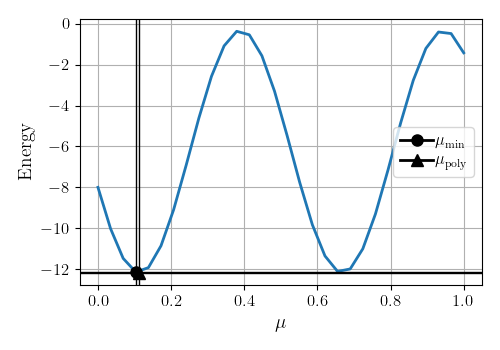

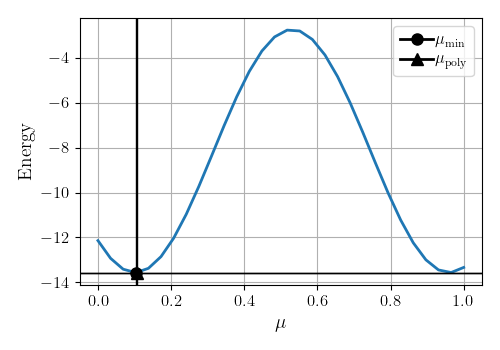

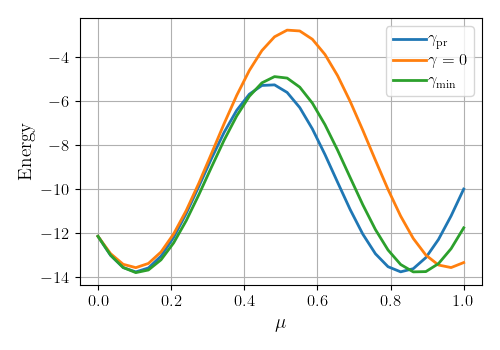

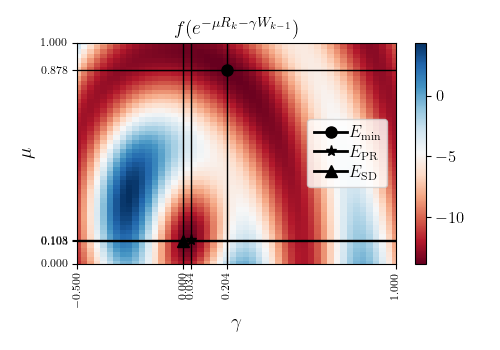

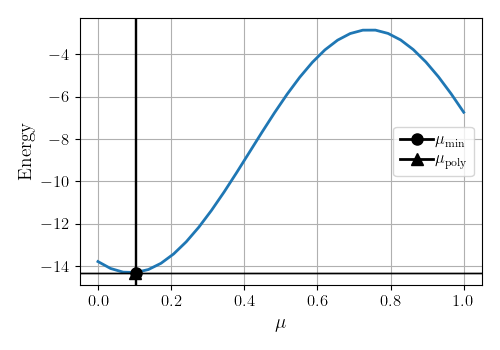

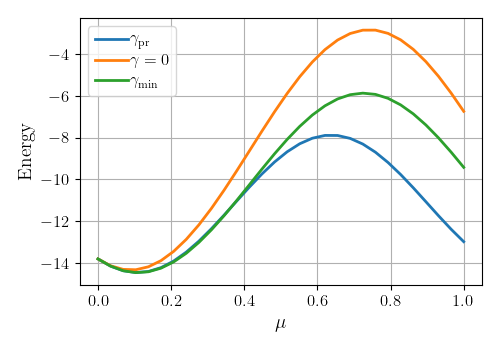

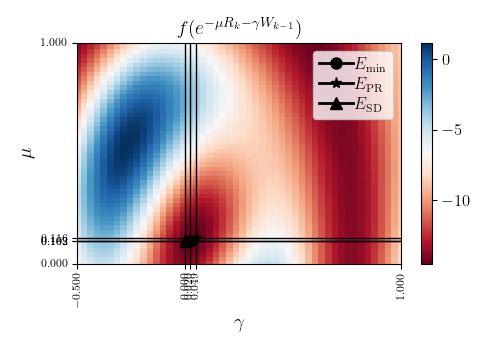

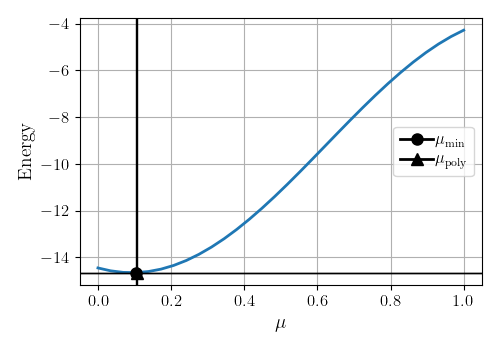

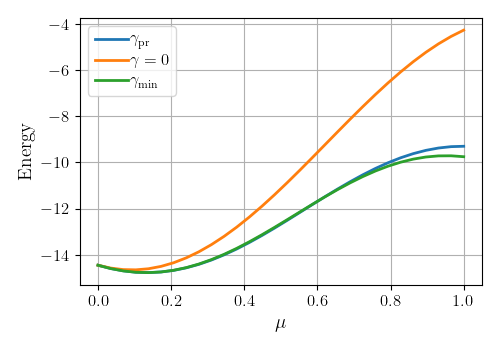

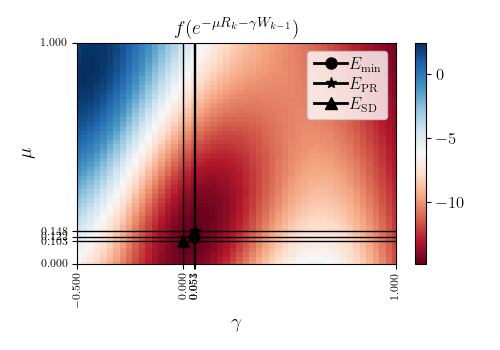

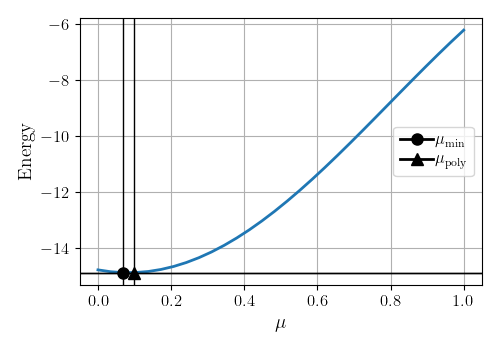

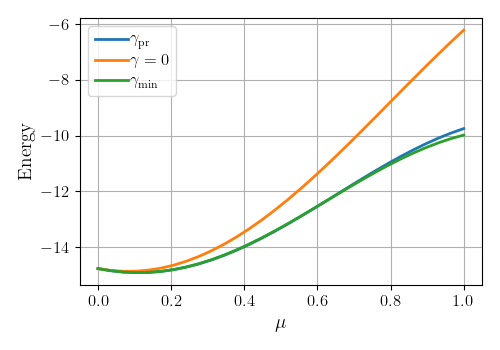

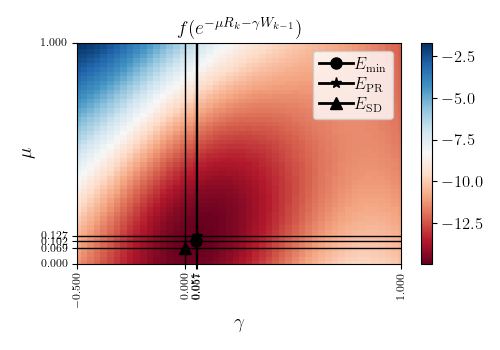

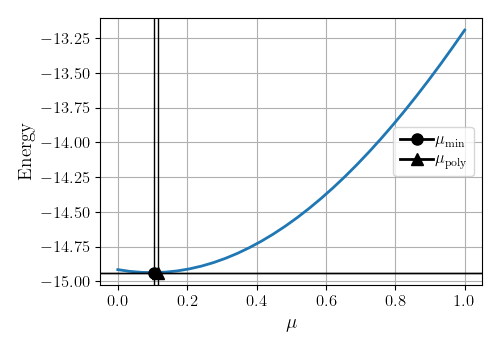

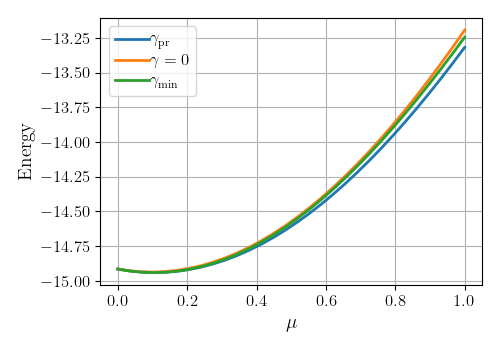

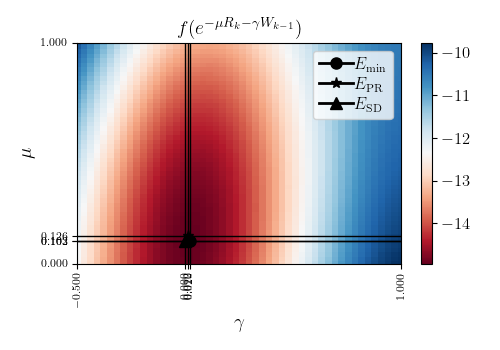

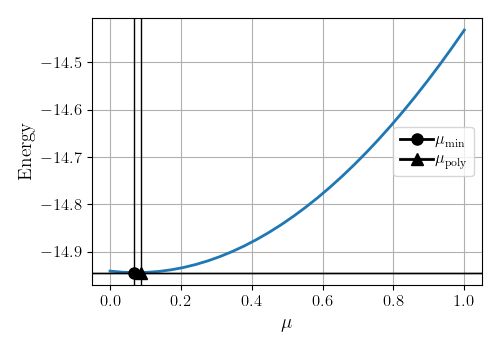

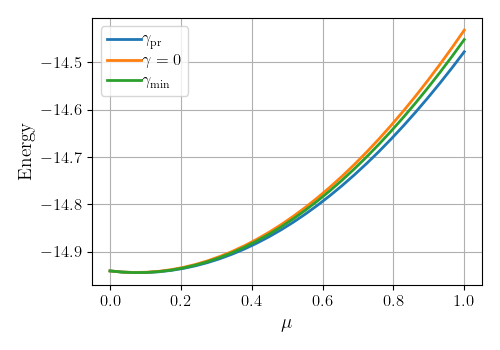

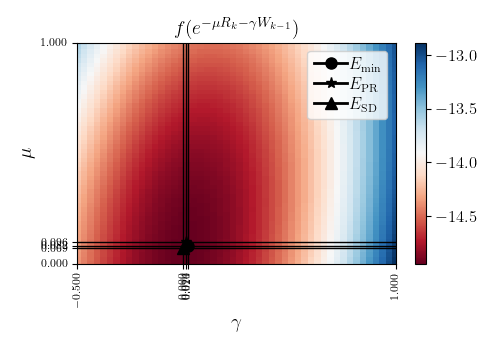

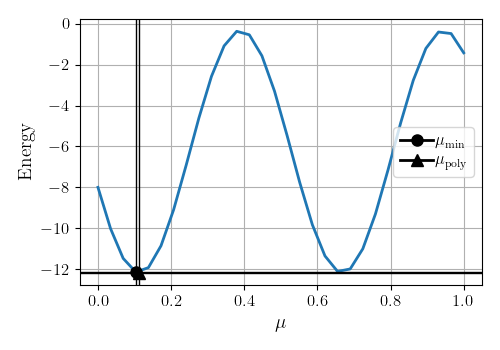

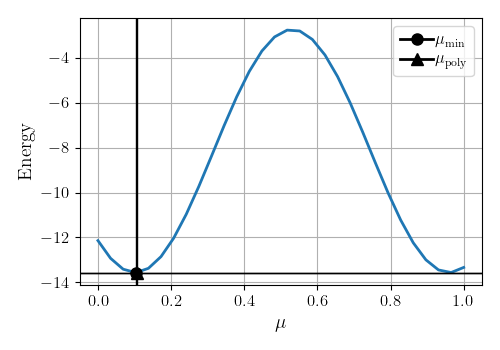

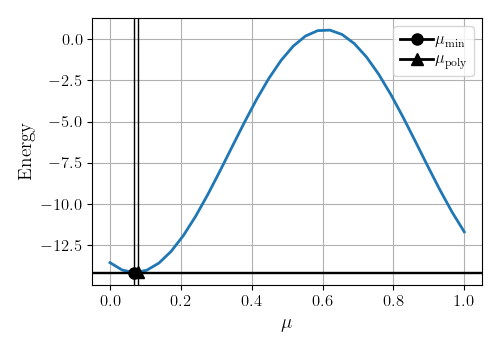

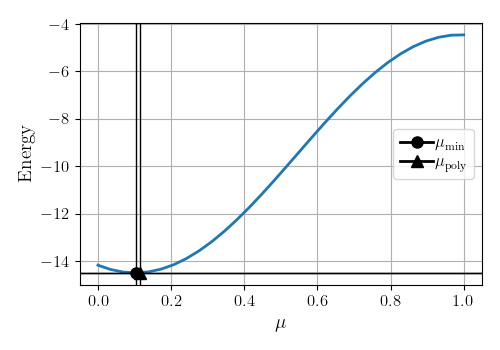

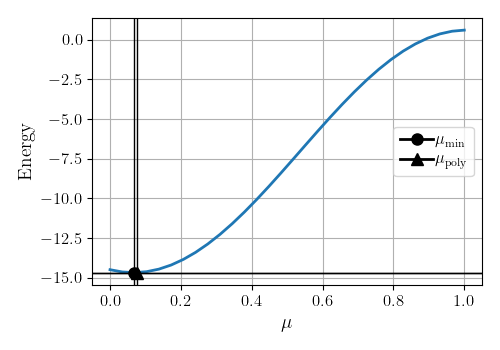

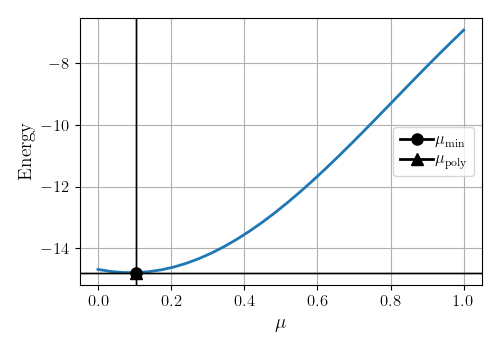

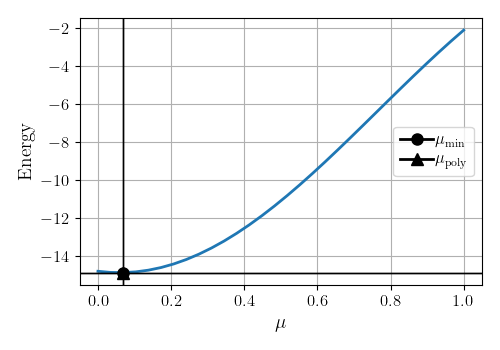

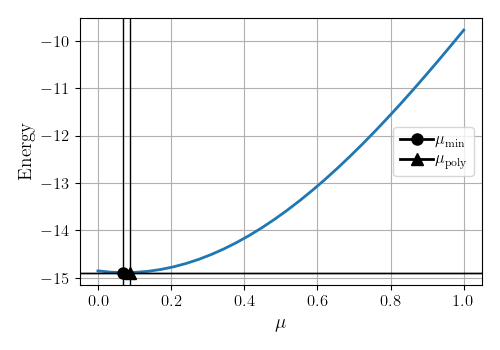

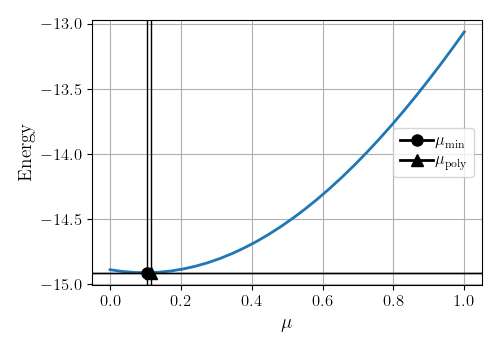

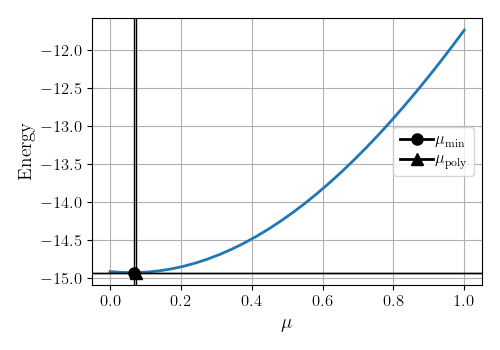

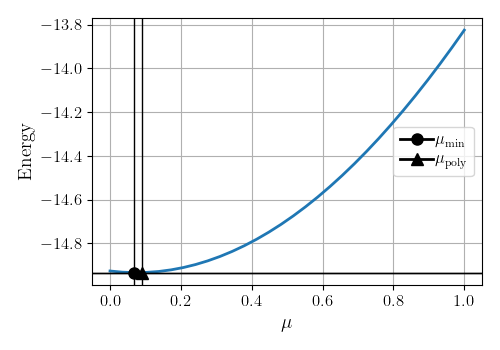

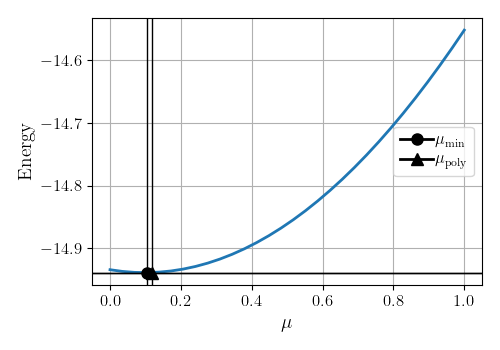

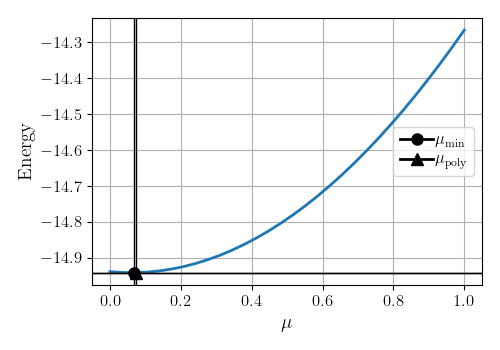

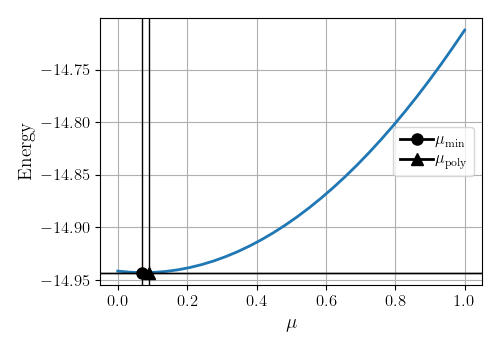

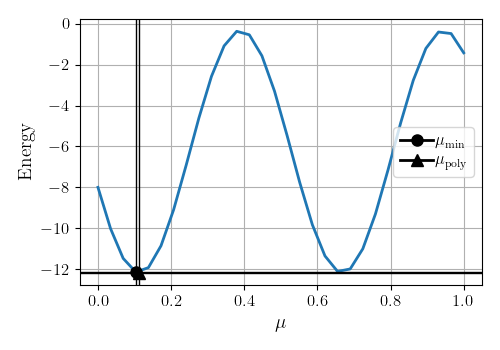

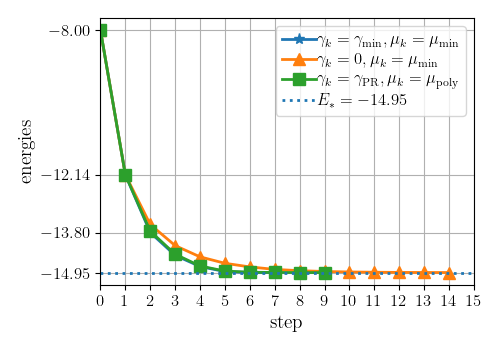

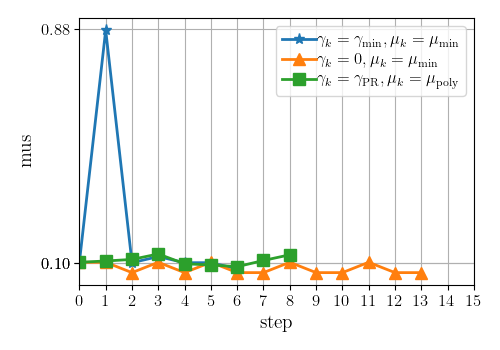

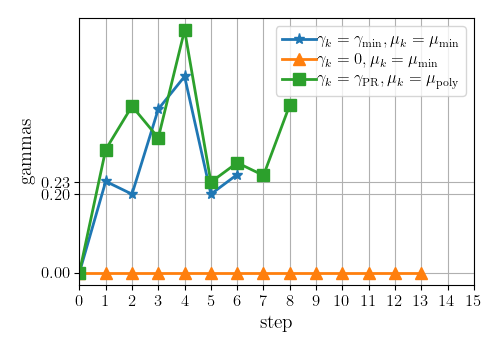

In [328]:
print("target energy is", target_energy)
toplot = []

grid_CG = general_cg(mu_line_search, mu_gamma_grid_searchA, "$\gamma_k = \gamma_\mathrm{min}, \mu_k = \mu_\mathrm{min}$", "*")
toplot.append(grid_CG)

line_SD = general_cg(mu_line_search, mu_line_search, "$\gamma_k = 0, \mu_k = \mu_\mathrm{min}$", "^")
toplot.append(line_SD)

# poly_SD = general_cg(mu_poly_approx, mu_poly_approx, "$\gamma_k = 0, \mu_k = \mu_\mathrm{poly}$", "p")
# toplot.append(poly_SD)

auto_pr_CG = general_cg(mu_line_search, mu_gamma_auto_PR, "$\gamma_k = \gamma_\mathrm{PR}, \mu_k = \mu_\mathrm{poly}$", "s")
toplot.append(auto_pr_CG)

# line_pr_CG = general_cg(mu_line_search, mu_line_gamma_PR, "$\gamma_k = \gamma_\mathrm{PR}, \mu_k = \mu_\mathrm{min}$", "o")
# toplot.append(line_pr_CG)

# plot energies
iter_plot(toplot, "energies", hlines=[{"mark": target_energy, "label": f"$E_* = {np.round(target_energy,2)}$"}])
iter_plot(toplot, "mus")
iter_plot(toplot, "gammas")